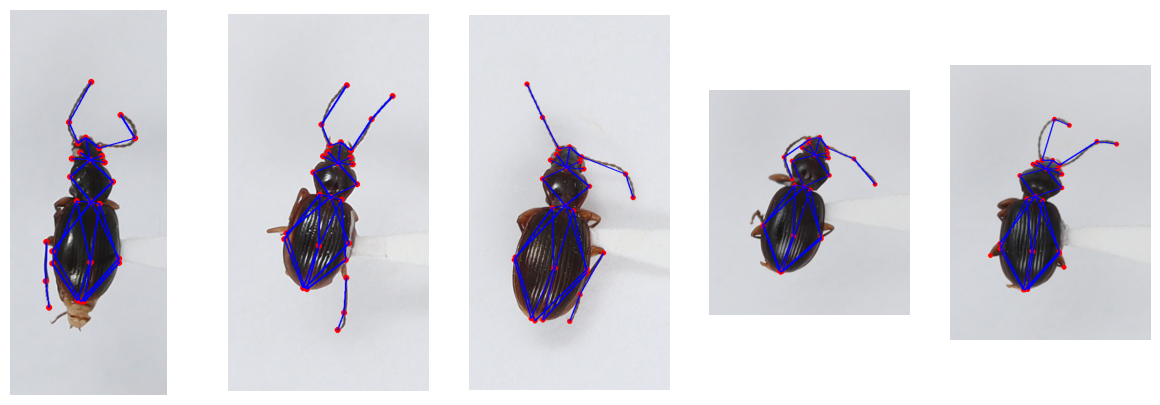

In [1]:
import os
import matplotlib.pyplot as plt
import yaml
import pathlib
import PIL.Image as Image, PIL.ImageDraw as ImageDraw

def visualize_annotation(dataset_name, num, dataset_dir = "../models/datasets/", split_dir="train", show_kp=True, show_lines=True):
    dataset_path = pathlib.Path(dataset_dir) / dataset_name 
    showed_images = sorted(( dataset_path / "images" / split_dir).glob("*.png"))[:num]
    showed_labels = sorted((dataset_path / "labels" / split_dir).glob("*.txt"))[:num]
    config = yaml.safe_load(open(dataset_path / "yolo-config.yaml", "r"))
    skeleton = config.get("skeleton", [])
    
    fig, axes = plt.subplots(1, num, figsize=(15, 5))

    for img_name, label_name in zip(showed_images, showed_labels):

        img = Image.open(img_name)
        w, h = img.size

        # draw bbox
        draw = ImageDraw.Draw(img)
        with open(label_name, "r") as f:
            for line in f:
                line = line.strip().split()
                cls, x_center, y_center, width, height = line[:5]
                if show_kp:
                    kpts = line[5:]
                    kpts = [float(kpt) for kpt in kpts]
                    kpts = list(zip(kpts[0::3], kpts[1::3], kpts[2::3])) # (x,y,visible)
                    for x, y, v in kpts:
                        if v > 0:
                            draw.ellipse((x*w-5, y*h-5, x*w+5, y*h+5), fill="red")
                    
                    if show_lines:
                        for idx1, idx2 in skeleton:
                            x1, y1, v1 = kpts[idx1]
                            x2, y2, v2 = kpts[idx2]
                            if v1 > 0 and v2 > 0:
                                draw.line((x1*w, y1*h, x2*w, y2*h), fill="blue", width=3)

        axes[showed_images.index(img_name)].imshow(img)
        axes[showed_images.index(img_name)].axis("off")
    
    plt.show()

visualize_annotation("fuzed", num=5, split_dir="train", show_kp=True, show_lines=True)


In [2]:
from ultralytics import YOLO
import time as t
import os
import numpy as np
from ultralytics import YOLO
from glob import glob
import cv2
import json

DATASET_NAME = "fuzed"

#  MODEL_PATH = "./runs/pose/train/weights/best.pt"
TEST_IMAGES = f"./datasets/{DATASET_NAME}/images/test/"
TEST_LABELS = f"./datasets/{DATASET_NAME}/labels/test/"

IMG_SIZE = 640
CONF = 0.25
DIST_THRESHOLD = 0.05  # seuil normalisé (5% de la bbox)

# model = YOLO(MODEL_PATH)

def load_yolo_pose_label(label_path):
    """
    Format YOLO pose :
    class cx cy w h kpt1_x kpt1_y v1 kpt2_x kpt2_y v2 ...
    """
    with open(label_path, "r") as f:
        line = f.readline().strip().split()

    values = list(map(float, line))

    # bbox
    cx, cy, w, h = values[1:5]

    # keypoints
    kpts = np.array(values[5:]).reshape(-1, 3)[:, :2]  # (x, y)

    return np.array([cx, cy, w, h]), kpts


def denormalize(kpts, img_w, img_h):
    kpts[:, 0] *= img_w
    kpts[:, 1] *= img_h
    return kpts


def bbox_size_pixels(bbox, img_w, img_h):
    _, _, w, h = bbox
    return np.sqrt((w * img_w) * (h * img_h))

In [7]:
model = "yolo26x-pose"

with open("run_results.json") as f:
    all_models = json.load(f)

if model not in all_models:
    all_models[model] = {"name" : f"{model}.pt", "training time" : 0, "keypoints perf":[], "metrics" : []}

print(f"\nTraining {model}")
loaded_model = YOLO(all_models[model]["name"])
T1 = t.time()
results_yolo = loaded_model.train(data=f"./datasets/{DATASET_NAME}/yolo-config.yaml", epochs=150, imgsz=640)
all_models[model]['traning time'] = t.time() - T1

all_errors = []

image_paths = glob(os.path.join(TEST_IMAGES, "*.jpg")) + glob(os.path.join(TEST_IMAGES, "*.png"))

for img_path in image_paths:
    label_path = os.path.join(
        TEST_LABELS,
        os.path.basename(img_path).replace(".jpg", ".txt").replace(".png", ".txt")
    )

    if not os.path.exists(label_path):
        continue

    # Load GT
    bbox_gt, kpts_gt = load_yolo_pose_label(label_path)

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    kpts_gt = denormalize(kpts_gt.copy(), w, h)

    # Predict
    res_yolo = loaded_model.predict(img_path, conf=CONF, verbose=False)

    if len(res_yolo[0].keypoints) != 0:
        kpts_pred = res_yolo[0].keypoints.xy[0].cpu().numpy()
        errors = np.linalg.norm(kpts_pred - kpts_gt, axis=1)
        all_errors.append(errors)

all_errors = np.array(all_errors)

all_models[model]["keypoints perf"] = all_errors.mean(axis=0).tolist()

with open("run_results.json", "w") as f:
    json.dump(all_models, f, indent=2)



Training yolo26x-pose
Ultralytics 8.4.33 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 7805MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/fuzed/yolo-config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26x-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train22, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

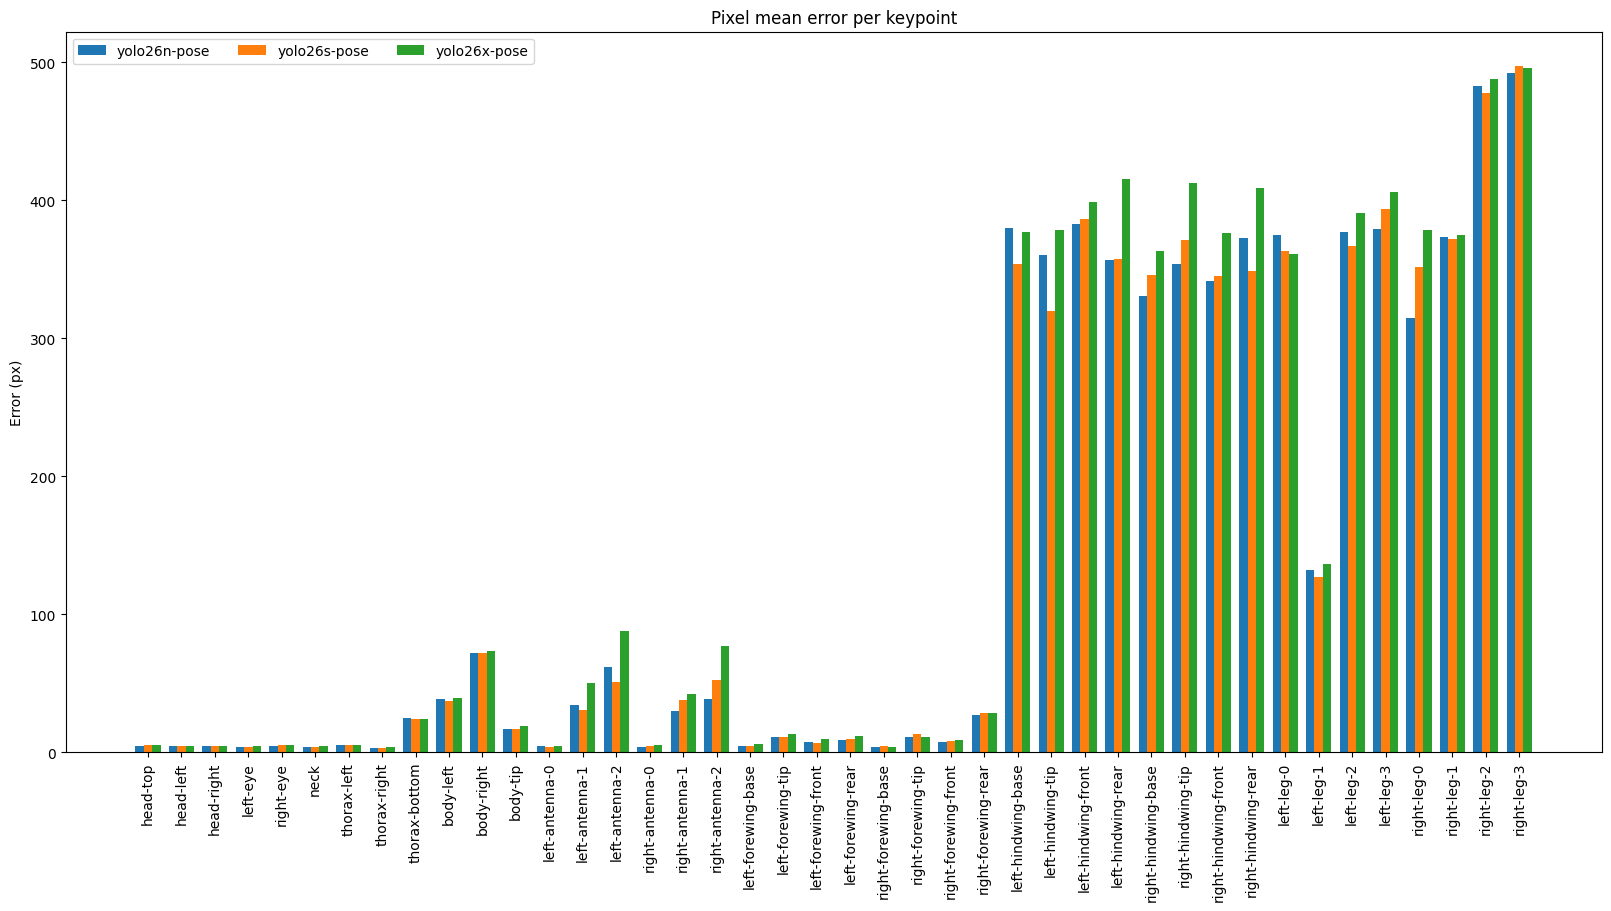

In [3]:
import matplotlib.pyplot as plt
import yaml

with open(f"./datasets/{DATASET_NAME}/yolo-config.yaml", "r") as f:
    config = yaml.safe_load(f)

with open("run_results.json", "r") as f:
    models_data = json.load(f)

all_kp = config["kpt_names"][0]

mean_error_yolo_n = models_data["yolo26n-pose"]["keypoints perf"]
mean_error_yolo_s = models_data["yolo26s-pose"]["keypoints perf"]
mean_error_yolo_x = models_data["yolo26x-pose"]["keypoints perf"]

num_kpts = len(mean_error_yolo_n)
x = np.arange(num_kpts)

x = np.arange(42)  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(16, 9))

for attribute, measurement in models_data.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement["keypoints perf"], width, label=attribute)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Error (px)')
ax.set_title('Pixel mean error per keypoint')
ax.set_xticks(x + width, all_kp, rotation=90)
ax.legend(loc='upper left', ncols=3)

plt.show()

fig.savefig("perf_comparison_results.png")
plt.show()

/tmp/ipykernel_284365/3825420532.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


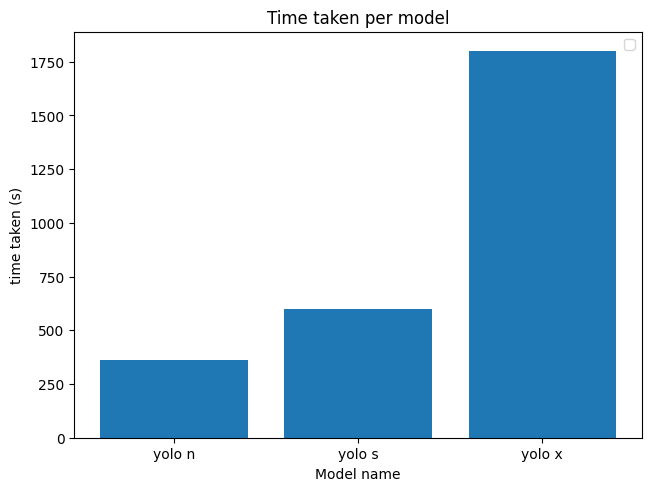

In [4]:
fig, ax = plt.subplots(layout="constrained")

ax.bar(["yolo n", "yolo s", "yolo x"], [models_data["yolo26n-pose"]["training time"], models_data["yolo26s-pose"]["training time"], models_data["yolo26x-pose"]["training time"]]
)
ax.set_xlabel("Model name")
ax.set_ylabel("time taken (s)")
ax.set_title("Time taken per model")
ax.legend()

fig.savefig("time_comparison.png")
plt.show()